# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
Deep learning models learn patterns directly from data instead of relying on hand crafted rules.
Recurrent neural networks process text one word at a time and carry a hidden memory forward
through the sequence. A vanilla recurrent network struggles to remember information from many
steps in the past because gradients shrink as they flow backward through time. Long short term
memory networks solve this problem using input, forget, and output gates that protect important
information inside a dedicated memory cell. Gated recurrent units simplify this idea using only
two gates while still capturing long range dependencies efficiently. Each of these architectures
can be trained on a corpus of text to predict the next word given the previous words, and the
resulting model can then generate new sentences word by word. Comparing simple recurrent
networks against long short term memory and gated recurrent unit networks on the same corpus
reveals how gating mechanisms improve memory retention and produce more coherent generated text.
'''

def clean_text(text):
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

corpus = clean_text(corpus)
print(corpus)

deep learning models learn patterns directly from data instead of relying on hand crafted rules recurrent neural networks process text one word at a time and carry a hidden memory forward through the sequence a vanilla recurrent network struggles to remember information from many steps in the past because gradients shrink as they flow backward through time long short term memory networks solve this problem using input forget and output gates that protect important information inside a dedicated memory cell gated recurrent units simplify this idea using only two gates while still capturing long range dependencies efficiently each of these architectures can be trained on a corpus of text to predict the next word given the previous words and the resulting model can then generate new sentences word by word comparing simple recurrent networks against long short term memory and gated recurrent unit networks on the same corpus reveals how gating mechanisms improve memory retention and produce

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

token_list = tokenizer.texts_to_sequences([corpus])[0]

input_sequences = []
for i in range(1, len(token_list)):
    n_gram_seq = token_list[: i + 1]
    input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Max sequence length:", max_len)

Vocabulary size: 114
X shape: (160, 160)
y shape: (160,)
Max sequence length: 161


In [5]:
EMBED_DIM = 128
HIDDEN_UNITS = 128
EPOCHS = 200
OPTIMIZER = lambda: Adam(learning_rate=0.01)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_model = Sequential([
    Embedding(total_words, EMBED_DIM),
    SimpleRNN(HIDDEN_UNITS),
    Dropout(0.2),
    Dense(total_words, activation="softmax"),
])

rnn_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer=OPTIMIZER(),
                   metrics=["accuracy"])

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed | final loss:",
      round(rnn_history.history["loss"][-1], 4))

Vanilla RNN training completed | final loss: 0.0099


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
lstm_model = Sequential([
    Embedding(total_words, EMBED_DIM),
    LSTM(HIDDEN_UNITS),
    Dropout(0.2),
    Dense(total_words, activation="softmax"),
])

lstm_model.compile(loss="sparse_categorical_crossentropy",
                    optimizer=OPTIMIZER(),
                    metrics=["accuracy"])

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed | final loss:",
      round(lstm_history.history["loss"][-1], 4))

LSTM training completed | final loss: 0.0006


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [9]:
gru_model = Sequential([
    Embedding(total_words, EMBED_DIM),
    GRU(HIDDEN_UNITS),
    Dropout(0.2),
    Dense(total_words, activation="softmax"),
])

gru_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer=OPTIMIZER(),
                   metrics=["accuracy"])

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed | final loss:",
      round(gru_history.history["loss"][-1], 4))

GRU training completed | final loss: 0.0002


## 📉 Compare Training Loss

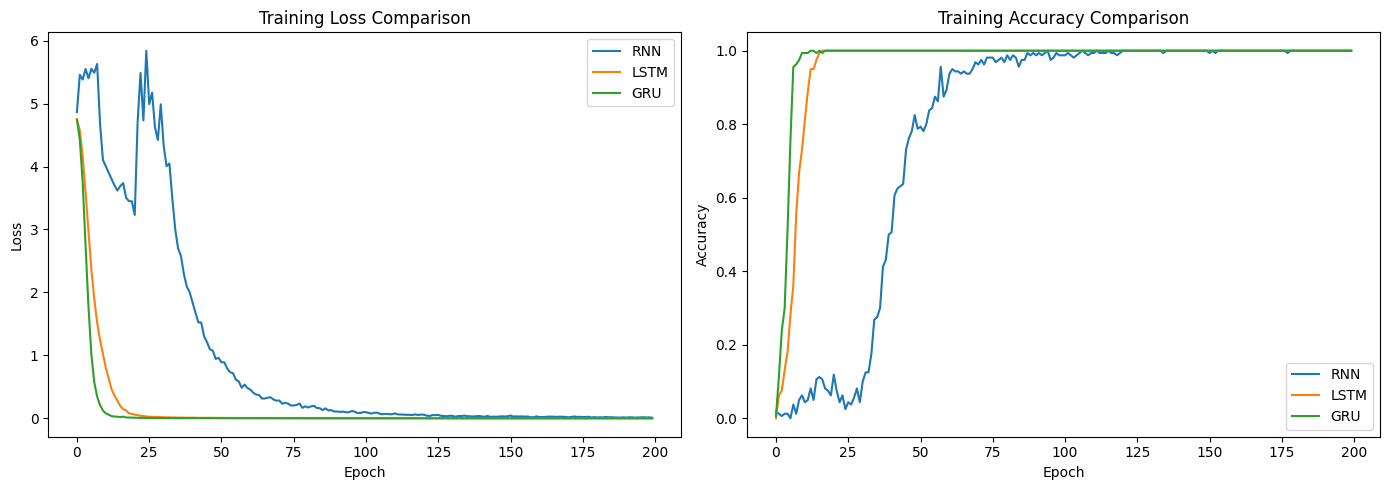

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history["loss"], label="RNN")
axes[0].plot(lstm_history.history["loss"], label="LSTM")
axes[0].plot(gru_history.history["loss"], label="GRU")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].legend()

axes[1].plot(rnn_history.history["accuracy"], label="RNN")
axes[1].plot(lstm_history.history["accuracy"], label="LSTM")
axes[1].plot(gru_history.history["accuracy"], label="GRU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding="pre")
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        if output_word == "":
            break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [12]:
seed = "deep learning models"

print("RNN :", generate_text(rnn_model, seed, 10))
print("LSTM:", generate_text(lstm_model, seed, 10))
print("GRU :", generate_text(gru_model, seed, 10))

RNN : deep learning models learn patterns directly from data instead of relying on hand
LSTM: deep learning models learn patterns directly from data instead of relying on hand
GRU : deep learning models learn patterns directly from data instead of relying on hand


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**